In [1]:
import sys
sys.path.append('../src')

In [2]:
from extract import extrair_dados
from scoring import gera_score
from segmentacao import gera_segmentacao
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

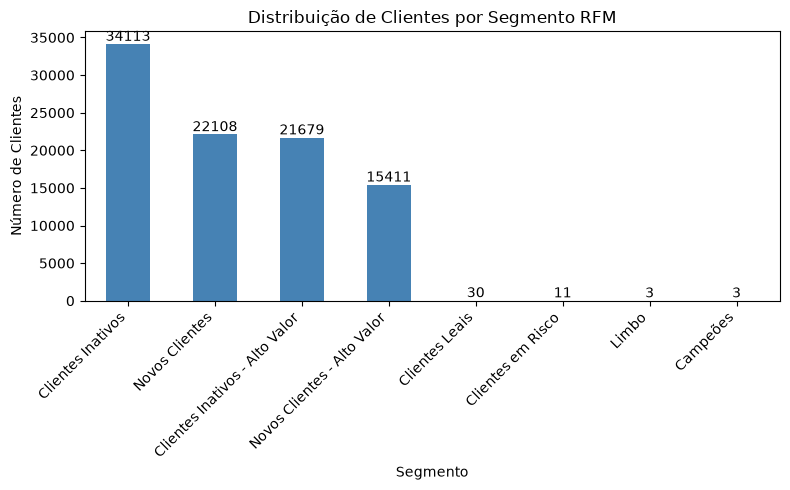

In [3]:
df_rfm = extrair_dados()
df_rfm = gera_score(df_rfm)
df_rfm = gera_segmentacao(df_rfm)

contagem_segmentos = df_rfm['segmento'].value_counts()

grafico = contagem_segmentos.plot(kind='bar', figsize=(8, 5), color='steelblue')

plt.title('Distribuição de Clientes por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.bar_label(grafico.containers[0])

plt.show()

In [4]:
"""
Essa primeira exibição mostra uma desproporção grande entre os dois principais grupos (clientes inativos e novos clientes) e os demais grupos.
"""

'\nEssa primeira exibição mostra uma desproporção grande entre os dois principais grupos (clientes inativos e novos clientes) e os demais grupos.\n'

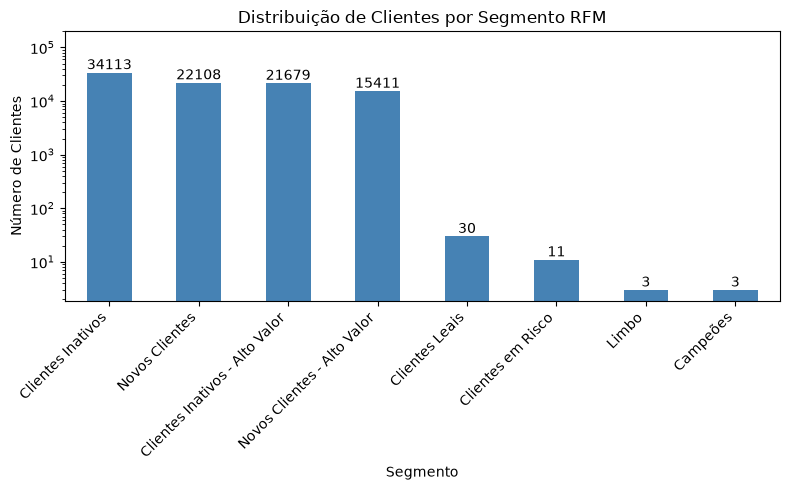

In [5]:
# aplicando escala logarítmica para facilitar a visualização dos grupos que ficaram muito pequenos na escala anterior

df_rfm = extrair_dados()
df_rfm = gera_score(df_rfm)
df_rfm = gera_segmentacao(df_rfm)

contagem_segmentos = df_rfm['segmento'].value_counts()

grafico = contagem_segmentos.plot(kind='bar', figsize=(8, 5), color='steelblue')

plt.title('Distribuição de Clientes por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.bar_label(grafico.containers[0])
plt.ylim(top=200000)

plt.show()

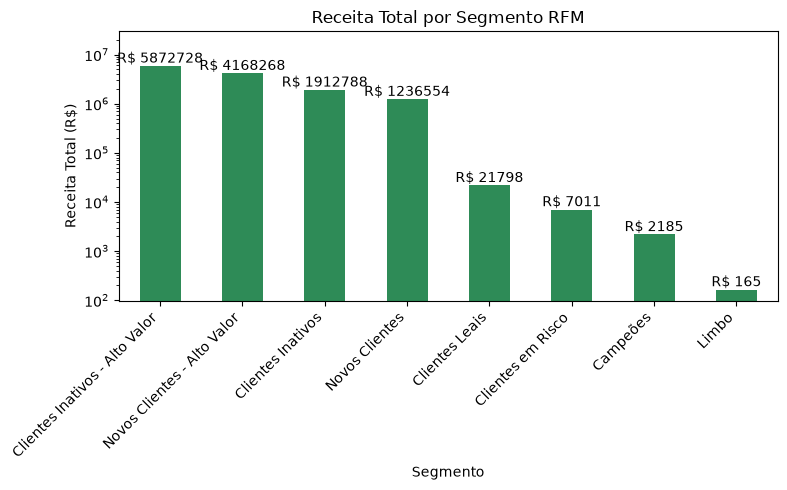

In [6]:
# entendendo a baixa recompra

receita_por_segmento = df_rfm.groupby('segmento')['total_price_per_client'].sum().sort_values(ascending=False)

grafico2 = receita_por_segmento.plot(kind='bar', figsize=(8, 5), color='seagreen')

plt.title('Receita Total por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Receita Total (R$)')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(top=plt.ylim()[1] * 3)
plt.bar_label(grafico2.containers[0], fmt='R$ %.0f')

plt.show()

In [7]:
"""
Clientes inativos e novos clientes são a maioria. Faz sentido sustentarem a receita total.
"""

'\nClientes inativos e novos clientes são a maioria. Faz sentido sustentarem a receita total.\n'

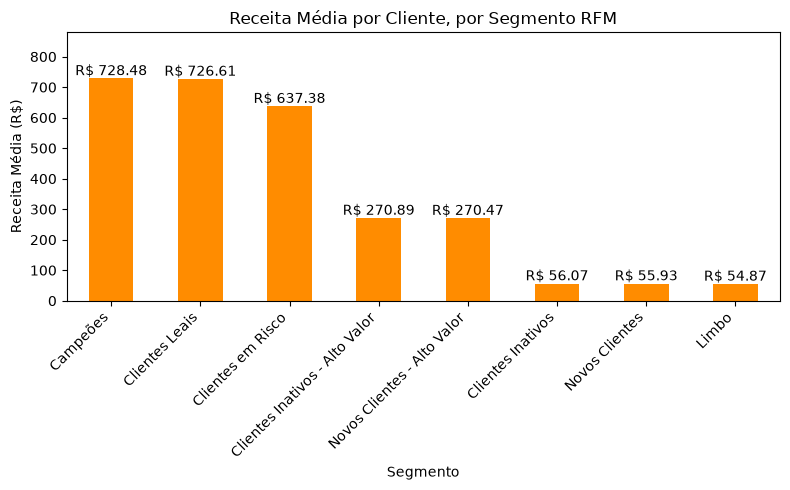

In [8]:
receita_media_por_segmento = df_rfm.groupby('segmento')['total_price_per_client'].mean().sort_values(ascending=False)

grafico3 = receita_media_por_segmento.plot(kind='bar', figsize=(8, 5), color='darkorange')

plt.title('Receita Média por Cliente, por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Receita Média (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(top=plt.ylim()[1] * 1.15)
plt.bar_label(grafico3.containers[0], fmt='R$ %.2f')

plt.show()

In [ ]:
"""
Individualmente, os campeões, leais e em risco valem mais, mas como representam uma pequena parte do todo eles não contribuem em quase nada para a receita total. Os novos clientes e 
clientes inativos têm baixo valor individual, mas sustentam o faturamento total por serem a maioria.
"""

'\nIndividualmente, os campeões, leais e em risco valem mais, mas como representam uma pequena parte do todo eles não contribuem em quase nada para a receita total. Os novos clientes e clientes inativos\ntêm baixo valor individual, mas sustentam o faturamento total por serem a maioria.\n'

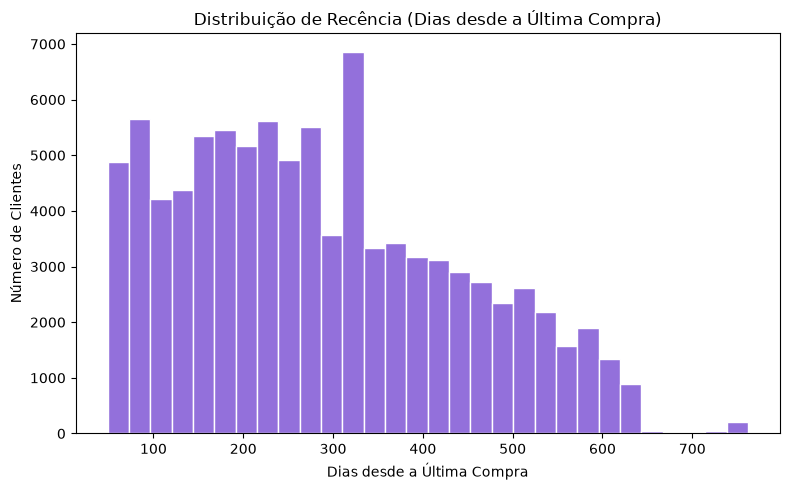

In [10]:
# pesquisando insights sobre sazonalidade

plt.figure(figsize=(8, 5))
plt.hist(df_rfm['days_last_purchase'], bins=30, color='mediumpurple', edgecolor='white')

plt.title('Distribuição de Recência (Dias desde a Última Compra)')
plt.xlabel('Dias desde a Última Compra')
plt.ylabel('Número de Clientes')
plt.tight_layout()

plt.show()

In [ ]:
# entendendo por que um valor ficou bem mais acima que os outros

conexao = sqlite3.connect('../sql/dados.db')

query = """
SELECT 
    DATE(order_purchase_timestamp) AS data,
    COUNT(*) AS total_pedidos
FROM orders
WHERE order_status = 'delivered'
    AND order_purchase_timestamp BETWEEN '2017-11-01' AND '2017-12-31'
GROUP BY DATE(order_purchase_timestamp)
ORDER BY total_pedidos DESC
LIMIT 10
"""

estudo_sazonalidade = pd.read_sql_query(query, conexao)
conexao.close()

print("Dias com mais pedidos")
print(estudo_sazonalidade)

Dias com mais pedidos
         data  total_pedidos
0  2017-11-24           1147
1  2017-11-25            487
2  2017-11-27            395
3  2017-11-26            382
4  2017-11-28            372
5  2017-12-04            322
6  2017-11-29            314
7  2017-12-06            269
8  2017-12-05            269
9  2017-11-23            268


In [12]:
"""
24 de novembro de 2017 foi o dia da Black Friday.
"""

'\n24 de novembro de 2017 foi o dia da Black Friday.\n'

In [ ]:
# verificando se os segmentos de maior ticket médio não estão inflados comparando média e mediana

segmentos = ['Campeões', 'Clientes Leais', 'Clientes em Risco']

for s in segmentos:
    valores = df_rfm[df_rfm['segmento'] == s]['total_price_per_client']
    print(f"{s} (clientes={len(valores)})")
    print(f"média: {valores.mean():,.2f}")
    print(f"mediana: {valores.median():,.2f}")
    print(f"mín: {valores.min():,.2f}  máx: {valores.max():,.2f}")
    print(valores.sort_values(ascending=False).to_string(index=False))
    print()

Campeões (clientes=3)
média: 728.48
mediana: 714.63
mín: 664.20  máx: 806.61
806.61
714.63
664.20

Clientes Leais (clientes=30)
média: 726.61
mediana: 520.81
mín: 200.28  máx: 4,080.00
4080.00
1686.90
1650.00
1535.40
 994.80
 866.79
 697.84
 687.76
 670.39
 633.97
 633.16
 597.90
 579.81
 574.47
 547.14
 494.48
 439.40
 438.09
 422.35
 404.57
 393.86
 365.70
 364.30
 356.92
 334.50
 327.19
 281.20
 279.60
 259.49
 200.28

Clientes em Risco (clientes=11)
média: 637.38
mediana: 569.48
mín: 288.00  máx: 1,047.00
1047.00
1000.85
 836.60
 809.21
 681.60
 569.48
 487.89
 486.00
 404.80
 399.70
 288.00



In [24]:
# investigando cliente outlier em clientes leais por conta da diferença entre média e mediana

cliente_outlier = df_rfm[
    (df_rfm['segmento'] == 'Clientes Leais') & 
    (df_rfm['total_price_per_client'] == 4080)
]

cliente_outlier[['customer_unique_id', 'days_last_purchase', 'total_purchases', 'total_price_per_client', 'R_score', 'F_score', 'M_score']]

,customer_unique_id,days_last_purchase,total_purchases,total_price_per_client,R_score,F_score,M_score
73127,c8460e4251689ba205045f3ea17884a1,70,4,4080.0,5,3,5


In [ ]:
""""
recência = 5, frequência = 3 e monetário = 5, é um cliente realmente valioso e não deve ser tratado como sujeira de base
"""